**For PyTorch purposes only!**

In [1]:
import torch
n = 5
grid = torch.zeros((n,n), dtype=torch.int64)
print(grid)
print(grid.shape)
print(grid.dtype)
print(grid.device)

tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]])
torch.Size([5, 5])
torch.int64
cpu


In [2]:
import torch
print(torch.cuda.is_available())

True


In [3]:
print(torch.cuda.get_device_name(0))

NVIDIA GeForce RTX 2060


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [6]:
import torch
n = 5
grid = torch.zeros((n,n), dtype=torch.int64, device=device)
print(grid)
print(grid.shape)
print(grid.dtype)
print(grid.device)

tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]], device='cuda:0')
torch.Size([5, 5])
torch.int64
cuda:0


In [7]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

x = torch.rand((10000,10000), device=device)
y = torch.rand((10000,10000), device=device)

z = x @ y

print(z.device)

cuda:0


In [8]:
grid[2, 2] = 1
print(grid)

tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]], device='cuda:0')


In [10]:
directions = torch.tensor([
    [0, 1],
    [-1, 0],
    [1, 0],
    [0, -1]
])
print(directions.shape)

torch.Size([4, 2])


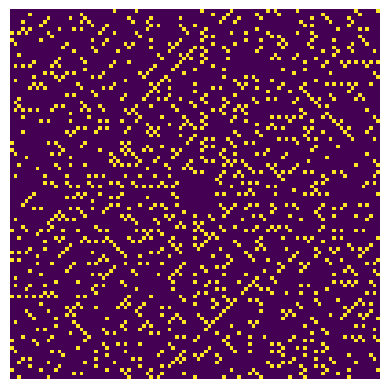

In [43]:
import torch
import matplotlib.pyplot as plt
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n = 101
grid = torch.zeros((n, n), dtype = torch.int64, device=device)
center = n//2
x = center
y = center
grid[x, y] = 1

directions = torch.tensor([
    [0, +1],
    [-1, 0],
    [0, -1],
    [+1, 0]
], device=device)

current_number = 2
step_len = 1
turn_ctr = 0
dir_index = 0

while current_number <= n*n:
    for _ in range(2):
        direction = directions[dir_index]
        for _ in range(step_len):
            if current_number > n*n:
                break
            dx, dy = direction
            x += dx
            y += dy
            grid[x,y] = current_number
            current_number += 1 
        dir_index = (dir_index + 1) % 4
    step_len += 1
# print(grid)
numbers = grid.view(-1) # flatten everything in one line
# print(numbers)
# print(numbers.shape)
max_num = numbers.max()
# print(max_num)
limit = int(torch.sqrt(max_num.float()))
# print(limit)
divisor = torch.arange(2, limit+1, device=device)
# print(divisor)
# print(divisor.shape)
numbers = numbers.unsqueeze(1)      #Each number is now its own row
# print(numbers.shape)
reminder = numbers % divisor
# print(reminder.shape)
divisible = (reminder == 0)
# print(divisible.shape)
composite = divisible.any(dim=1)
# print(composite.shape)
prime_mask = ~composite
prime_mask[numbers.squeeze() == 1] = False
prime_mask = prime_mask.view(n,n)
# print(prime_mask)

plt.imshow(prime_mask.cpu())
plt.axis("off")
plt.show()

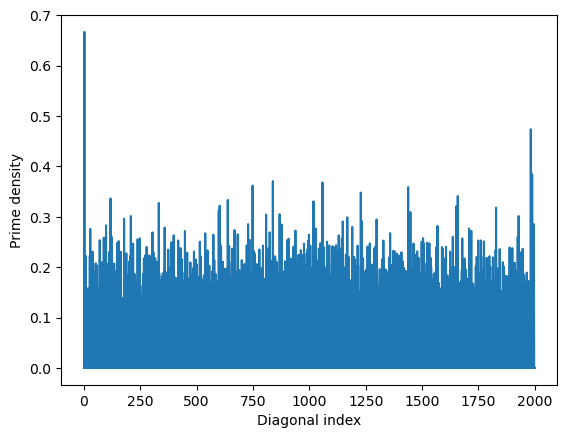

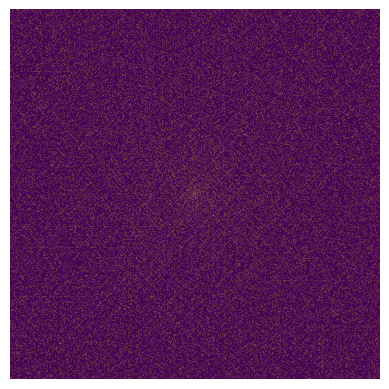

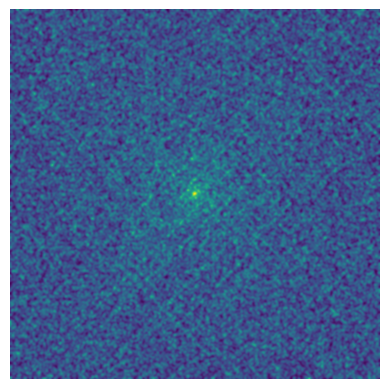

In [49]:
import torch
import matplotlib.pyplot as plt
import scipy.ndimage

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n = 1001
N= n*n
grid = torch.zeros((n, n), dtype = torch.int64, device=device)
center = n//2
x = center
y = center
grid[x, y] = 1

directions = torch.tensor([
    [0, +1],
    [-1, 0],
    [0, -1],
    [+1, 0]
], device=device)

current_number = 2
step_len = 1
turn_ctr = 0
dir_index = 0

while current_number <= n*n:
    for _ in range(2):
        direction = directions[dir_index]
        for _ in range(step_len):
            if current_number > n*n:
                break
            dx, dy = direction
            x += dx
            y += dy
            grid[x,y] = current_number
            current_number += 1 
        dir_index = (dir_index + 1) % 4
    step_len += 1
# print(grid)
is_prime = torch.ones(N+1, dtype=torch.bool, device=device)
is_prime[0] = False
is_prime[1] = False
limit = int(N**0.5)
for i in range(2, limit+1):
    if is_prime[i]:
        is_prime[i*i : N+1 : i] = False
prime_mask = is_prime[grid]
diag_counts = []

for k in range(-n+1, n):
    diag = prime_mask.diagonal(offset=k)
    diag_counts.append(diag.float().mean().item())

plt.plot(diag_counts)
plt.xlabel("Diagonal index")
plt.ylabel("Prime density")
plt.show()
rotated = scipy.ndimage.rotate(prime_mask.cpu().float(), 45, reshape=True)
plt.imshow(rotated)
plt.imshow(prime_mask.cpu())
plt.axis("off")
plt.show()
from scipy.ndimage import gaussian_filter
blur = gaussian_filter(prime_mask.cpu().float(), sigma=3)
plt.imshow(blur)
plt.axis("off")
plt.show()